# Validações Estatísticas do BeamNG como Digital Twin

## 1. Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import correlate
from os import listdir
import ast

## 2. Carregar dados

In [57]:
# ---------------- REAL ----------------
reais = []
for file in listdir('circuito4/real'):
    reais.append(pd.read_csv(f'circuito4/real/{file}'))

print(f"Reais carregados: {len(reais)}")

# ---------------- SIMULADO ----------------
simulados = []
for file in listdir('circuito4/simulado_taxa_coleta_correta'):
    simulados.append(pd.read_csv(f'circuito4/simulado_taxa_coleta_correta/{file}', sep=';'))

print(f"Simulados carregados: {len(simulados)}")

Reais carregados: 10
Simulados carregados: 1


## 3. Preparação dos dados

In [58]:
def preparar_df(df):
    df = df.copy()

    # limpar nomes
    df.columns = df.columns.str.strip()

    # detectar coluna de tempo
    if 'Time (sec)' in df.columns:
        time_col = 'Time (sec)'
    elif 'time' in df.columns:
        time_col = 'time'
    else:
        raise ValueError("Coluna de tempo não encontrada")

    # ordenar
    df = df.sort_values(time_col)

    # converter tempo
    df[time_col] = pd.to_timedelta(df[time_col], unit='s')
    df = df.set_index(time_col)

    # converter numérico
    df = df.apply(pd.to_numeric, errors='coerce')

    # reamostrar (10 Hz)
    df = df.resample('100ms').mean().interpolate()

    return df

## 4. Criar datasets principais

In [59]:
real = preparar_df(reais[0])
simulado = preparar_df(simulados[0])

print("OK: dados preparados")

OK: dados preparados


## 5.  Sincronização + Lag

In [60]:
# REAL
real.rename(columns={
    'Posição D do pedal do acelerador (%)': 'throttle',
    'Longitude (deg)': 'posX',
    'Latitude (deg)': 'posY',
    'Altitude (m)': 'posZ'
}, inplace=True)

# SIMULADO já tem:
# throttle, posX, posY, posZ, vel

## 6. Alinhar tempo

In [61]:
real.index = real.index - real.index[0]
simulado.index = simulado.index - simulado.index[0]

## 7. Selecionar variáveis comparáveis

In [62]:
colunas = ['throttle', 'posX', 'posY', 'posZ']

## 8. Normalização

In [63]:
df_all = pd.concat([real[colunas], simulado[colunas]])

mean = df_all.mean()
std = df_all.std()

real_norm = (real[colunas] - mean) / std
sim_norm = (simulado[colunas] - mean) / std

## 9. Juntar datasets

In [64]:
df = pd.concat([
    real_norm.add_prefix('real_'),
    sim_norm.add_prefix('sim_')
], axis=1)

df = df.dropna()

print(df.head())

                        real_throttle  real_posX  real_posY  real_posZ  \
0 days 00:00:00             -0.950539   -0.16239  -0.169863  -1.014690   
0 days 00:00:00.100000      -0.950539   -0.16239  -0.169863  -0.989912   
0 days 00:00:00.200000      -0.950539   -0.16239  -0.169863  -0.965134   
0 days 00:00:00.300000      -0.950539   -0.16239  -0.169863  -0.940356   
0 days 00:00:00.400000      -0.950539   -0.16239  -0.169863  -0.915578   

                        sim_throttle  sim_posX  sim_posY  sim_posZ  
0 days 00:00:00            -0.950232  0.732983  0.852823 -0.263666  
0 days 00:00:00.100000     -0.948363  0.732407  0.852860 -0.264614  
0 days 00:00:00.200000     -0.946495  0.731831  0.852896 -0.265561  
0 days 00:00:00.300000     -0.944627  0.731255  0.852932 -0.266509  
0 days 00:00:00.400000     -0.942758  0.730679  0.852969 -0.267456  


## 10. Plot inicial

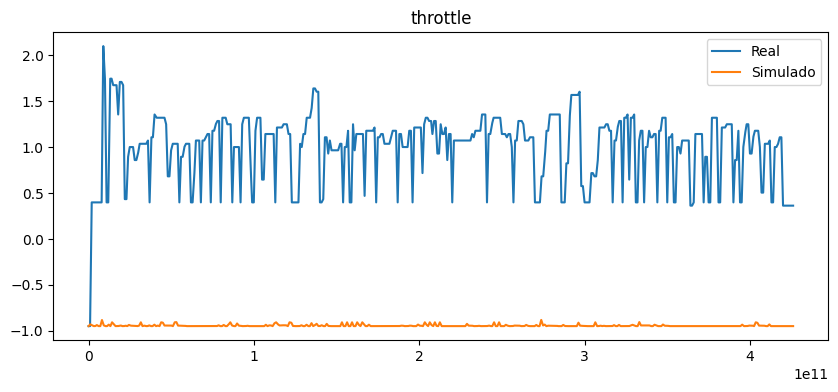

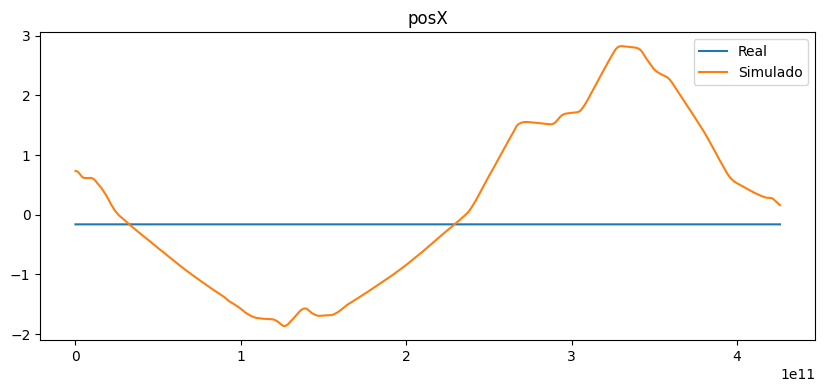

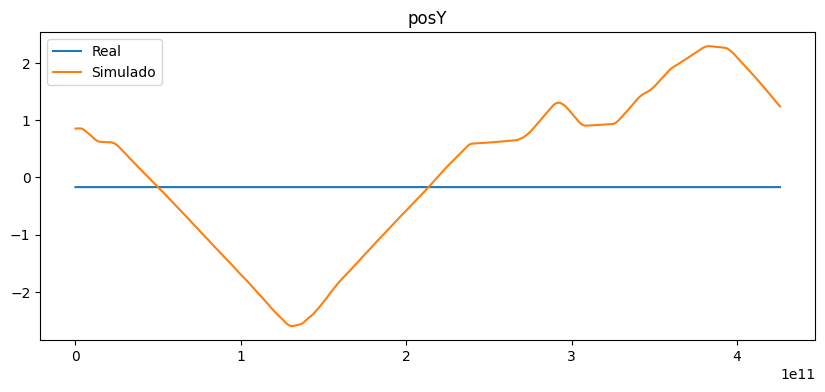

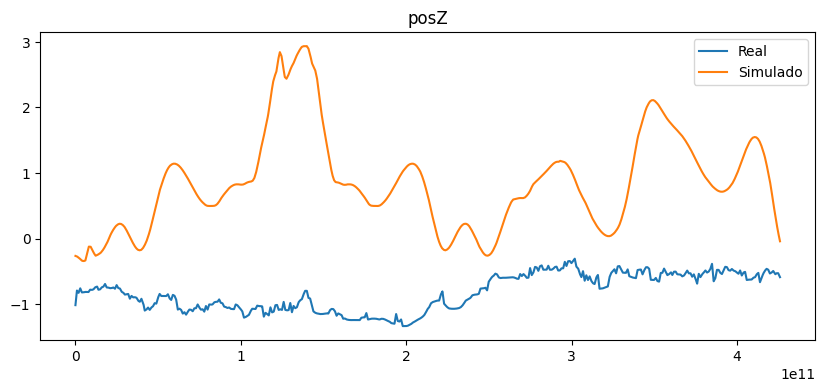

In [65]:
for col in colunas:
    plt.figure(figsize=(10,4))
    plt.plot(df[f'real_{col}'], label='Real')
    plt.plot(df[f'sim_{col}'], label='Simulado')
    plt.title(col)
    plt.legend()
    plt.show()

## 11. Correção de LAG

In [66]:
lags = {}

for col in colunas:
    x = df[f'real_{col}'].values
    y = df[f'sim_{col}'].values

    corr = correlate(x, y)
    lag = np.argmax(corr) - len(x)

    lags[col] = lag
    df[f'sim_{col}_shifted'] = df[f'sim_{col}'].shift(lag)

print("Lags detectados:", lags)

df = df.dropna()

Lags detectados: {'throttle': np.int64(-4245), 'posX': np.int64(1900), 'posY': np.int64(2071), 'posZ': np.int64(4053)}


## 12. Correlação de Pearson global

In [70]:
print("\n--- Correlação Global ---")

for col in colunas:
    
    x = df[f'real_{col}']
    y = df[f'sim_{col}_shifted']

    # remover NaN
    valid = (~x.isna()) & (~y.isna())
    x = x[valid]
    y = y[valid]

    # checagem de segurança
    if len(x) < 2:
        print(f"{col}: dados insuficientes ⚠️")
        continue

    r, p = pearsonr(x, y)

    print(f"{col}: r = {r:.3f} | p = {p:.5f}")
    print(df.shape)


--- Correlação Global ---
throttle: dados insuficientes ⚠️
posX: dados insuficientes ⚠️
posY: dados insuficientes ⚠️
posZ: dados insuficientes ⚠️


## 13. Correlação com JANELA DESLIZANTE

In [ ]:
window = 50  # ajuste se quiser

resultados = {}

for col in colunas:
    x = df[f'real_{col}'].values
    y = df[f'sim_{col}_shifted'].values

    corrs = []

    for i in range(len(x) - window):
        r, _ = pearsonr(x[i:i+window], y[i:i+window])
        corrs.append(r)

    resultados[col] = corrs

## 14. Plot da correlação dinâmica

In [ ]:
for col in colunas:
    plt.figure(figsize=(10,4))
    plt.plot(resultados[col])
    plt.title(f'Correlação dinâmica - {col}')
    plt.xlabel('Janela')
    plt.ylabel('Pearson')
    plt.grid()
    plt.show()

## 15. Plot FINAL (alinhado)

In [ ]:
for col in colunas:
    plt.figure(figsize=(10,4))

    plt.plot(df[f'real_{col}'], label='Real')
    plt.plot(df[f'sim_{col}_shifted'], label='Simulado (alinhado)', alpha=0.7)

    plt.title(f'Séries alinhadas - {col}')
    plt.legend()
    plt.show()